# Introduction to Image processing

In this lab, we are going to talk about geometric operations on images, then we will talk about the concept of sliding windows, finally, we will talk about filters and how to understand and implement them.

## Outline 
* Learn to apply different geometric transformations to images, like translation, rotation.
* Learn about sliding windows.
* Learn how to apply filters on images.

## References 
* [OpenCV Python Tutorials](https://docs.opencv.org/4.5.5/d6/d00/tutorial_py_root.html)
* [SciPy Singal Docs](https://docs.scipy.org/doc/scipy/reference/signal.html)


## 1: Importing libraries
The next code will contain the imports of various libraries, starting from NumPy, which is an essential library for our lab.


In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## 2: Geometric operations


### Translation
Translation is the shifting of an object's location. If you know the shift in the (x,y) direction and let it be (tx,ty), you can create the transformation matrix M as follows:

<center>
   M = [1 0 tx; 0 1 ty]
</center>

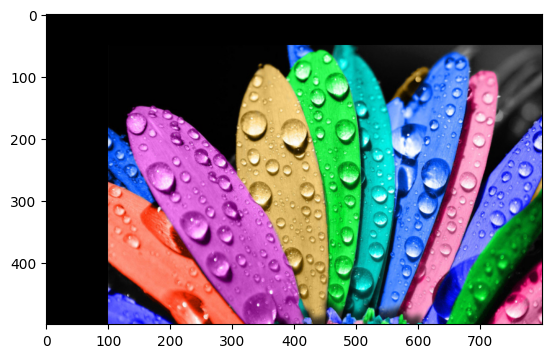

In [7]:
flower = cv2.imread('flower.jpg')
rows, cols, channels = flower.shape

M = np.array([[1,0,100],[0,1,50]]).astype('float32')
dst = cv2.warpAffine(flower,M,(cols,rows))
plt.imshow(dst)
plt.show()

according to OpenCV, `wrapAffine` will apply this formela to get each pixel:
<br/><br/>

<center>
  dst(x,y) = src( M_11 x + M_12 y + M_13 * M_21 x + M_22 y + M_23
</center>

#### Extra: Manual Wrap Affine

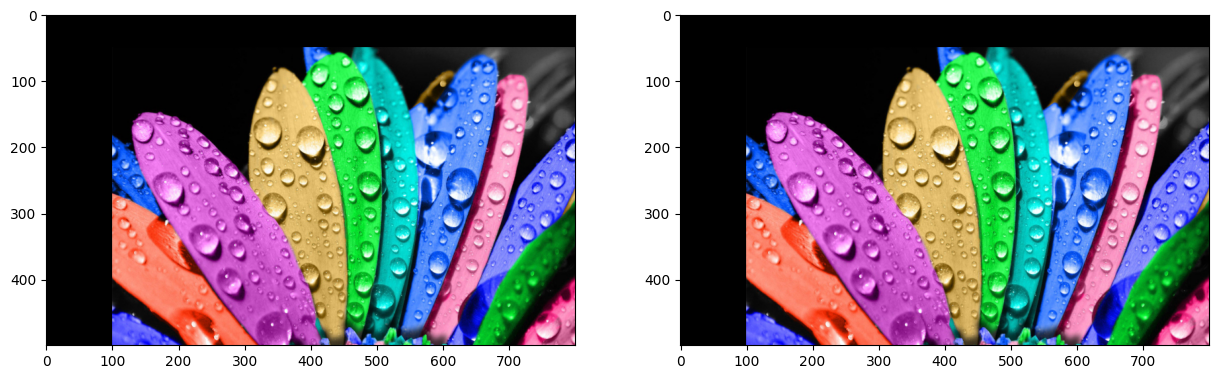

In [8]:
new_dst = np.zeros(flower.shape, dtype=flower.dtype)
for y in range(rows):
  for x in range(cols):
    # The @ is np.matmul, which is matrix multiplication
    new_pos = M @ np.array([x, y, 1])
    if new_pos[0] >= cols or new_pos[1] >= rows:
        break
    new_dst[int(new_pos[1]), int(new_pos[0])] = flower[y, x]
fig = plt.figure(figsize=(15,5))
axs = fig.subplots(1, 2)
axs[0].imshow(dst)
axs[1].imshow(new_dst)
plt.show()

### Image Resizing
Resizing an image is not a trivial operation, you might think that you will discard some pixels and display for example half of the pixels to get an image half the original size, but notice that when you resize an image, you might have fractions in pixels positions!

You could round the floating-point in the position of the new pixels, which means you are applying `nearest neighbour interpolation`.

luckily for us, we could use the `resize` function in OpenCV, which will handle all of this, and have many interpolations options [Take a look at the docs](https://docs.opencv.org/4.5.5/da/d54/group__imgproc__transform.html#ga5bb5a1fea74ea38e1a5445ca803ff121)

(500, 800, 3)
(500, 500, 3)


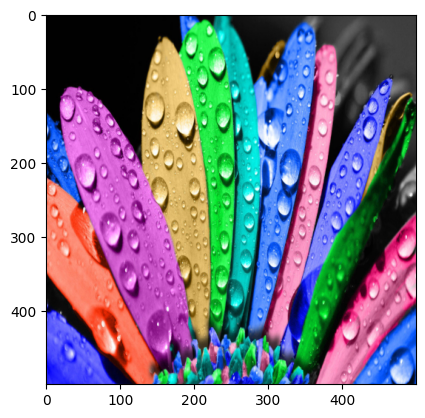

In [9]:
print(flower.shape)
flower2 = cv2.resize(flower,(500,500))
print(flower2.shape)
plt.imshow(flower2)
plt.show()

### Rotation
To rotate an image we will apply the same procedure as translating it, but with a diffrent transformation matrix, to rotate an image without having a center `(0,0) will be the center`, we could have this matrix:
<center>
    M = {cos(theta) -sin(theta) 0 ; sin(theta) cos(theta) 0}
</center>

or we could use `getRotationMatrix2D`, which will give us a matrix with the support of a custom center, and scale.

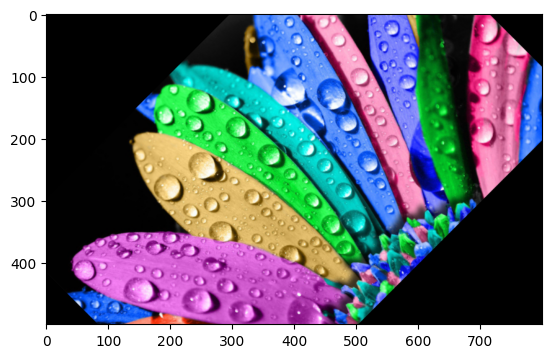

In [10]:
rows, cols, channels = flower.shape
center = (cols/2, rows/2)
M = cv2.getRotationMatrix2D(center,45, 1)
dst = cv2.warpAffine(flower,M,(cols,rows))

plt.imshow(dst)
plt.show()

### Perspective Transformation
For perspective transformation, you need a 3x3 transformation matrix. Straight lines will remain straight even after the transformation. To find this transformation matrix, you need 4 points on the input image and corresponding points on the output image. [[Ref]](https://docs.opencv.org/3.4/da/d6e/tutorial_py_geometric_transformations.html)

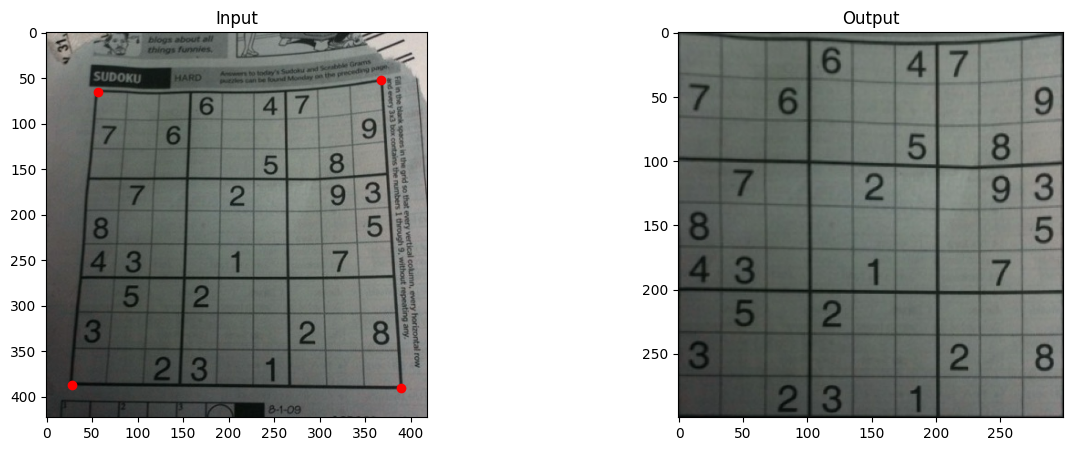

In [11]:
img = cv2.imread('sudoku.jpg')
rows, cols, ch = img.shape
# Points on the original image
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])
# Points on the new image
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

M = cv2.getPerspectiveTransform(pts1,pts2)
dst = cv2.warpPerspective(img, M, (300,300))

fig = plt.figure(figsize=(15,5))
axs = fig.subplots(1,2)

axs[0].set_title("Input")
axs[0].imshow(img)
axs[0].plot(pts1[:,0],pts1[:,1], 'ro')

axs[1].set_title("Output")
axs[1].imshow(dst)

plt.show()

## 3: Filters

Before talking about filters, we should understand the concept of a window, which is a region in the image, to apply the filter to an image, we could have a sliding window, which moves across the image.

### Sliding window
At any given point, any window that can be said to be a subset of a given particular data structure is known as a sliding window. The window size decides the number of elements that this subset would hold.

**Note:** You don't need to understand the following code, it's just here for demonstration.

C:\Users\HP\AppData\Local\Temp\ipykernel_2448\2903865039.py:26: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  anim = FuncAnimation(fig, animateWindow, interval=10)


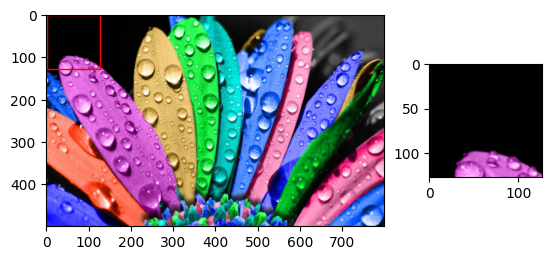

In [12]:
from matplotlib.animation import FuncAnimation
import matplotlib.patches as patches

rows, cols, channels = flower.shape
fig, axs = plt.subplots(1,2, gridspec_kw={'width_ratios': [3, 1]})
axs[0].imshow(flower)
rect = patches.Rectangle((1, 0), 127, 127, linewidth=1, edgecolor='r', facecolor='none')
axs[0].add_patch(rect)
axs[1].imshow(flower)
axs[1].set_xlim(0,127)
axs[1].set_ylim(127,0)

def animateWindow(frame_num):
    cX, cY = rect.get_xy()
    cX += 10
    if (cX >= cols - 127):
        cX = 1
        cY += 10
    if (cY >= rows - 127):
        cX = 1
        cY = 0
    rect.set_xy((cX, cY))
    axs[1].set_xlim(cX,cX+127)
    axs[1].set_ylim(cY+127,cY+0)
    return rect
anim = FuncAnimation(fig, animateWindow, interval=10)
plt.show()

In [13]:
plt.close(fig)

### Applying filter

To apply a filter, we will do a convolution between the kernel and the image, which means that we will apply the kernel to each window in the image, then get the final result, note that you could move the window by factors (e.g. += 10), so the output could be smaller than the original image.

![convolution-calculate.png](./convolution-calculate.jpg)

### Mean filter

The mean filter will blur the image, this could be achived by getting the average pixel color of the window, so if our kernel size is 3, you will have the following matrix:
<center>
    kernel = 1/9* {1  1  1 ; 1  1  1 ; 1  1  1}
</center>

In [14]:
# Sample pixel
y = 99
x = 249

walking = cv2.imread('walking.jpg',0)
old_value = walking[y,x]
print("Pixel (249, 99) Color: "+str(old_value))

ksize = 3
hksize = ksize//2 # half kernel size
kernel = np.array([[1,1,1],[1,1,1],[1,1,1]]).astype('float') / 9
print("\nKernel: ")
print(kernel)

# Get window
window = walking[y-hksize : y+hksize+1, x-hksize : x+hksize+1]
print("\nWindow: ")
print(window)
new_pixel_value = (window*kernel).sum()
print("\nNew Pixel Color: "+str(new_pixel_value))

Pixel (249, 99) Color: 189

Kernel: 
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

Window: 
[[ 30 189 184]
 [ 28 189 184]
 [ 26 188 184]]

New Pixel Color: 133.55555555555554


#### Applying the kernel manually

In [15]:
%time
rows, cols = walking.shape
im_out = np.zeros((walking.shape))
kernel = np.ones((15,15)) / (15 * 15)
ksize  = 15
hksize = ksize//2
for y in range(hksize, rows-hksize):
    for x in range(hksize, cols-hksize):
        region = walking[y-hksize : y+hksize+1 , x-hksize : x+hksize+1]
        im_out[y,x] = (region*kernel).sum()
                

CPU times: total: 0 ns
Wall time: 11.9 μs


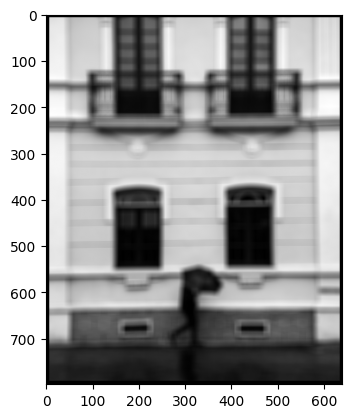

In [16]:
plt.imshow(im_out, cmap="gray")
plt.show()

#### Applying the kernel using `OpenCV.filter2D`

In [17]:
%time
im_out2 = cv2.filter2D(walking, -1, kernel)

CPU times: total: 0 ns
Wall time: 5.72 μs


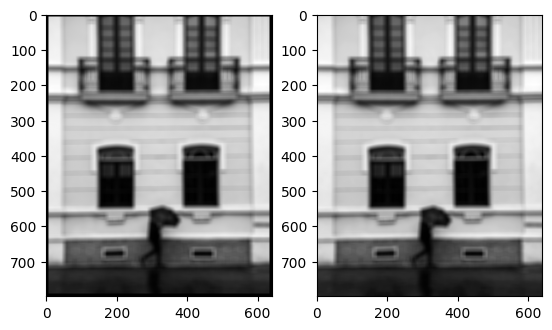

In [18]:
plt.gray()
plt.subplot(1,2,1)
plt.imshow(im_out)
plt.subplot(1,2,2)
plt.imshow(im_out2)
plt.show()

#### Applying the kernel using `scipy`

In [19]:
from scipy.signal import convolve2d

In [20]:
%time
im_out3 = convolve2d(walking, kernel)

CPU times: total: 0 ns
Wall time: 7.87 μs


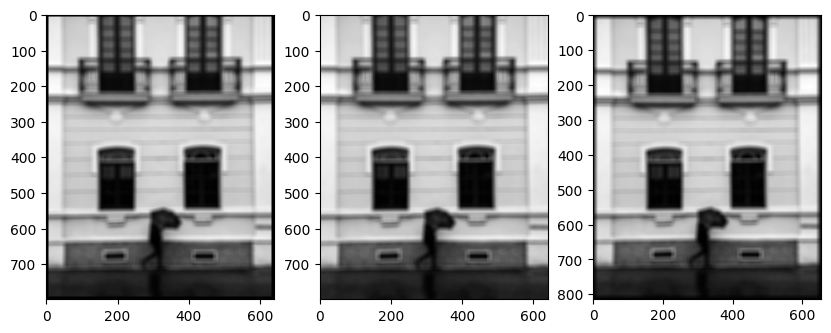

In [21]:
plt.figure(figsize=(10,5))
plt.gray()
plt.subplot(1,3,1)
plt.imshow(im_out)
plt.subplot(1,3,2)
plt.imshow(im_out2)
plt.subplot(1,3,3)
plt.imshow(im_out3)
plt.show()

Notice the borders!

###  Gaussian Filter
The Gaussian filter uses a gaussian function to generate the kernel, the gaussian function is the normal distribution of the pixels.

we will use `OpenCV.getGaussianKernel` to create a `1D` kernel, which we could apply on rows then on columns, which will lead to a faster code, but in our example, we will create a normal `2D` kernel, which we will apply using convolution.

Here is a sample 3x3 kernel from [wikipedia](https://en.wikipedia.org/wiki/Kernel_(image_processing)).

<center>
    $kernel = {{1} \over {16}}\begin{bmatrix} 1 & 2 & 1 \\ 2 & 4 & 2 \\ 1 & 2 & 1 \end{bmatrix}$
</center>

In [22]:
gaussina_1d = cv2.getGaussianKernel(3, 0)
print(gaussina_1d.flatten())

kernel = np.ones((3,3))
kernel *= gaussina_1d.T
kernel *= gaussina_1d
print("\nKernel: ")
print(kernel)

[0.25 0.5  0.25]

Kernel: 
[[0.0625 0.125  0.0625]
 [0.125  0.25   0.125 ]
 [0.0625 0.125  0.0625]]


In [23]:
standard_deviation = 5
gaussina_1d = cv2.getGaussianKernel(15, standard_deviation)
kernel = np.ones((15,15))
kernel *= gaussina_1d.T
kernel *= gaussina_1d

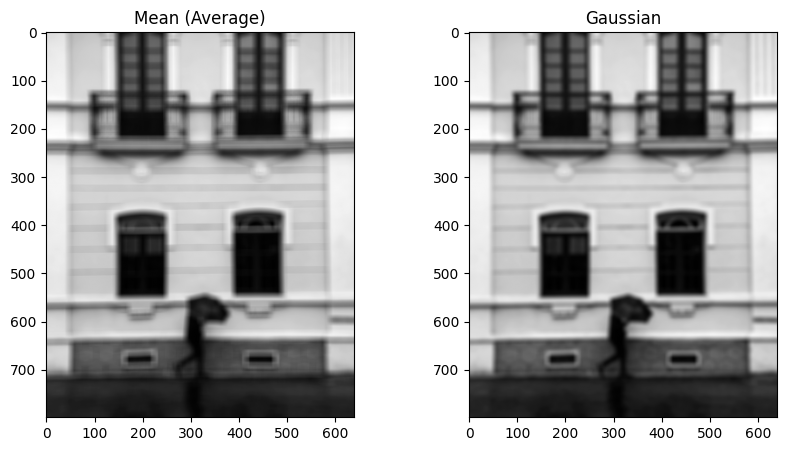

In [24]:
im_out_gaussian = cv2.filter2D(walking, -1, kernel)

plt.figure(figsize=(10,5))
plt.gray()
plt.subplot(1,2,1)
plt.imshow(im_out2)
plt.title("Mean (Average)")
plt.subplot(1,2,2)
plt.imshow(im_out_gaussian)
plt.title("Gaussian")
plt.show()

### Edge Detection using Derivative
To get the derivative of any function, we need to find the slop on each point, this could be achived using a simple kernel with the following values for horizontal edge detection:
<center>
    $kernel = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{bmatrix}$
</center>

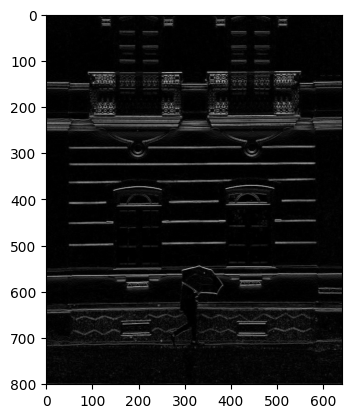

In [25]:
kernel = np.float32([[1,1,1], [0,0,0], [-1,-1,-1]])
im_out_hedge = np.abs(convolve2d(walking, kernel))
plt.imshow(im_out_hedge)
plt.show()

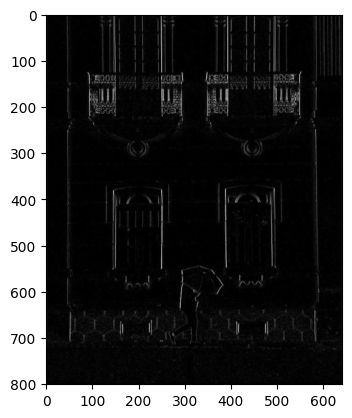

In [26]:
kernel = np.float32([[1,0,-1], [1,0,-1], [1,0,-1]])
im_out_vedge = np.abs(convolve2d(walking, kernel))
plt.imshow(im_out_vedge)
plt.show()

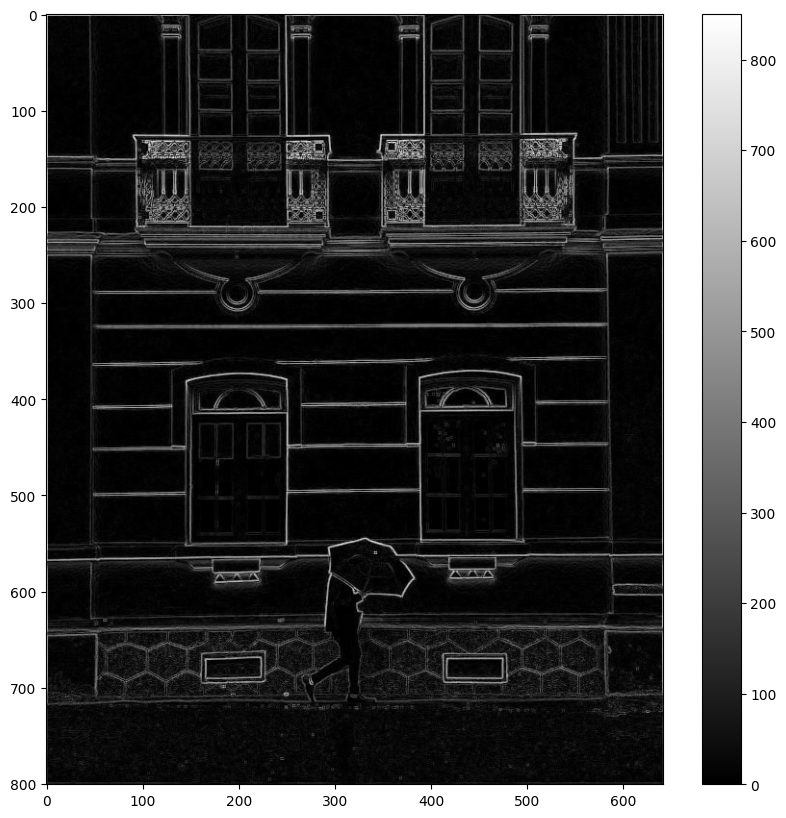

In [27]:
plt.figure(figsize=(10,10))
plt.imshow((im_out_hedge + im_out_vedge))
plt.colorbar()
plt.show()

#### Just for fun, real time filtering!

In [28]:
# Press Q to quit!
# Ref to capture video: https://docs.opencv.org/4.5.5/dd/d43/tutorial_py_video_display.html
cap = cv2.VideoCapture(0)
hkernel = np.float32([[1,0,-1], [1,0,-1], [1,0,-1]])
vkernel = np.float32([[1,1,1], [0,0,0], [-1,-1,-1]])
if not cap.isOpened():
    print("Cannot open camera")
while True:
    ret, frame = cap.read()
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    vimage = np.abs(convolve2d(gray, vkernel))
    himage = np.abs(convolve2d(gray, hkernel))
    new_frame = (vimage+himage)
    new_frame /= new_frame.max() 
    cv2.imshow('frame', new_frame)
    if cv2.waitKey(1) == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

<center>
    <h4>End of Lab 4</h4>
</center>